1. Use Google Colabs and Python to visualize California's Congressional Districts.  The data set is found here Download here.



In [24]:
from google.colab import drive
drive.mount('/content/drive')
%pushd "/content/drive/MyDrive/MSSP607/Data/"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/MSSP607/Data


['/content/drive/My Drive/MSSP607/Data', '/content']

In [2]:
!pip install geojson
!pip install geodatasets
!pip install mapclassify

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 882.2/882.2 kB 13.5 MB/s eta 0:00:00


In [4]:
import pandas as pd
import geojson as gpd
import geopandas as gp
import matplotlib.pyplot as plt
import mapclassify
import geopandas
import geodatasets
from geodatasets import get_path


2. Overlay the Population of the California Legislative districts on the congressional districts found here Download here.

3.  Create a visualization of the California Congressional districts from the geospatial data set, including a heatmap of the state.

4.  Upload the completed Jupyter Notebook to the Canvas assignment space.

In [18]:
pf = gp.read_file('california-congressional-districts.geojson')
pf.head(20)

,Name,description,descriptio,geometry
0,01,None,,"MULTIPOLYGON (((-120.07192 41.99495, -120.0010..."
1,02,None,,"MULTIPOLYGON (((-123.69821 41.81719, -123.6967..."
2,03,None,,"MULTIPOLYGON (((-121.667 39.30511, -121.63015 ..."
3,04,None,,"MULTIPOLYGON (((-120.37731 37.61679, -120.3823..."
4,05,None,,"MULTIPOLYGON (((-122.16384 38.64288, -122.1659..."
5,06,None,,"MULTIPOLYGON (((-121.58536 38.50271, -121.5876..."
6,07,None,,"MULTIPOLYGON (((-121.39055 38.50386, -121.386 ..."
7,08,None,,"MULTIPOLYGON (((-115.54096 35.72504, -115.4180..."
8,09,None,,"MULTIPOLYGON (((-121.6809 37.87442, -121.68865..."
9,10,None,,"MULTIPOLYGON (((-120.45827 37.68688, -120.4433..."


In [19]:
df = pd.read_csv('CA_Legislative_Districts.csv')
df.head()

,OBJECTID,ID,AREA,DISTRICT,MEMBERS,NAME,POPULATION,CVAP_19,HSP_CVAP_1,DOJ_NH_BLK,...,MULTIPLE_F,F_CVAP_19,F_HSP_CVAP,F_DOJ_NH_B,F_DOJ_NH_A,F_NH_WHT_C,DISTRICT_L,DISTRICT_N,SHAPE_Length,SHAPE_Area
0,1,1,27014.63,1,1,MTCAP,760066,549203,77031,10923,...,1|0,0.7226,0.1403,0.0199,0.0475,0.7507,1|0%,1,2.633906e+06,1.222952e+11
1,2,2,560.65,10,1,STANI,760066,503249,67160,26317,...,10|0,0.6621,0.1335,0.0523,0.1713,0.6220,10|0%,10,3.582890e+05,2.336909e+09
2,3,3,226.43,11,1,COCO,760067,568460,61171,33907,...,11|1,0.7479,0.1076,0.0596,0.3160,0.5006,11|0%,11,2.111932e+05,9.404054e+08
3,4,4,141.25,12,1,SF,760065,510978,74038,101894,...,12|-1,0.6723,0.1449,0.1994,0.2139,0.4169,12|-0%,12,1.246786e+05,5.869476e+08
4,5,5,6346.92,13,1,OKLND,760065,393416,197645,16042,...,13|-1,0.5176,0.5024,0.0408,0.0621,0.3708,13|-0%,13,1.186868e+06,2.578115e+10


In [21]:
pf['Name'] = pf['Name'].astype('float64')
pf.head()

,Name,description,descriptio,geometry
0,1.0,None,,"MULTIPOLYGON (((-120.07192 41.99495, -120.0010..."
1,2.0,None,,"MULTIPOLYGON (((-123.69821 41.81719, -123.6967..."
2,3.0,None,,"MULTIPOLYGON (((-121.667 39.30511, -121.63015 ..."
3,4.0,None,,"MULTIPOLYGON (((-120.37731 37.61679, -120.3823..."
4,5.0,None,,"MULTIPOLYGON (((-122.16384 38.64288, -122.1659..."


In [22]:
merged_districts = df.merge(pf, how='left', left_on='DISTRICT_N', right_on='Name')
merged_districts.head()

,OBJECTID,ID,AREA,DISTRICT,MEMBERS,NAME,POPULATION,CVAP_19,HSP_CVAP_1,DOJ_NH_BLK,...,F_DOJ_NH_A,F_NH_WHT_C,DISTRICT_L,DISTRICT_N,SHAPE_Length,SHAPE_Area,Name,description,descriptio,geometry
0,1,1,27014.63,1,1,MTCAP,760066,549203,77031,10923,...,0.0475,0.7507,1|0%,1,2.633906e+06,1.222952e+11,1.0,None,,"MULTIPOLYGON (((-120.07192 41.99495, -120.0010..."
1,2,2,560.65,10,1,STANI,760066,503249,67160,26317,...,0.1713,0.6220,10|0%,10,3.582890e+05,2.336909e+09,10.0,None,,"MULTIPOLYGON (((-120.45827 37.68688, -120.4433..."
2,3,3,226.43,11,1,COCO,760067,568460,61171,33907,...,0.3160,0.5006,11|0%,11,2.111932e+05,9.404054e+08,11.0,None,,"MULTIPOLYGON (((-121.73928 37.77212, -121.7803..."
3,4,4,141.25,12,1,SF,760065,510978,74038,101894,...,0.2139,0.4169,12|-0%,12,1.246786e+05,5.869476e+08,12.0,None,,"MULTIPOLYGON (((-122.5799 37.74808, -122.58128..."
4,5,5,6346.92,13,1,OKLND,760065,393416,197645,16042,...,0.0621,0.3708,13|-0%,13,1.186868e+06,2.578115e+10,13.0,None,,"MULTIPOLYGON (((-122.12665 37.72761, -122.1236..."


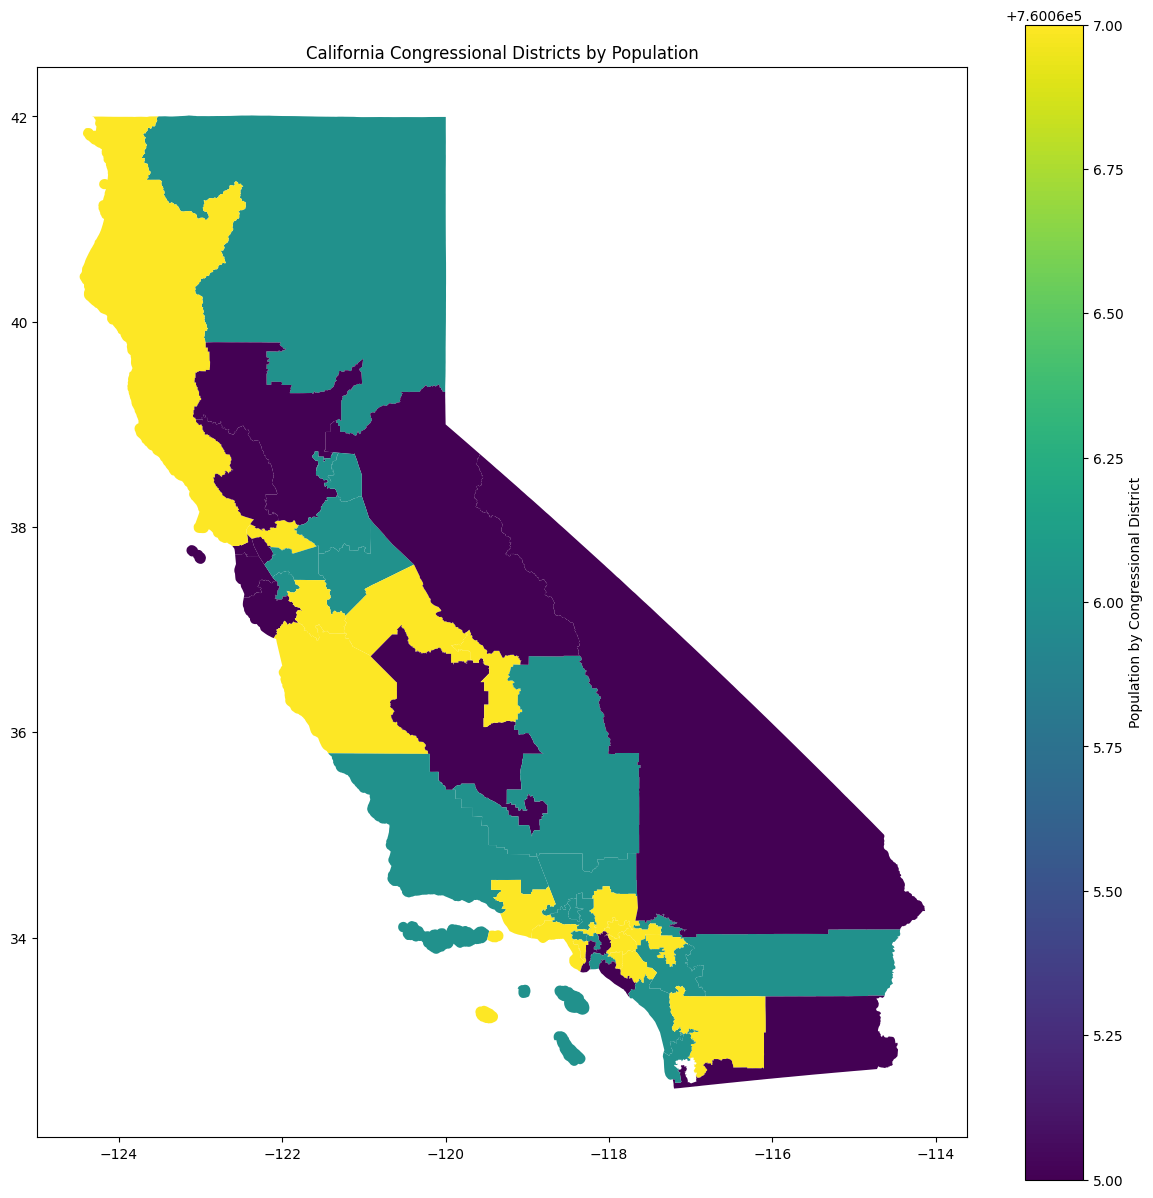

In [23]:
merged_districts_gdf = geopandas.GeoDataFrame(merged_districts, geometry='geometry')
fig, ax = plt.subplots(1, 1, figsize=(15, 15))
merged_districts_gdf.plot(column='POPULATION', ax=ax, legend=True,
                          legend_kwds={'label': "Population by Congressional District",
                                       'orientation': "vertical"})
ax.set_title('California Congressional Districts by Population')
plt.show()